# Generate Noise Traces

Build noise with `NoiseGenerator` and save a large batch to HDF5.

In [1]:
import h5py
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import yaml

from TraceSimulator import TraceSimulator, NoiseGenerator

def read_yaml_to_dict(file_path):
    with open(file_path, 'r') as file:
        return yaml.safe_load(file)

config = read_yaml_to_dict('/home/dwong/DELight_mtr/PCA_dev/reusable/PCA_config.yaml')
ts = TraceSimulator(config)
ng = NoiseGenerator(config)

print('noise_type =', config.get('noise_type'))
print('noise_power =', config.get('noise_power'))
print('sampling_frequency =', config.get('sampling_frequency'))


noise_type = /ceph/dwong/delight_conf/new/noise_psd_xray.npy
noise_power = 33.2
sampling_frequency = 3906250


single_noise shape: (37, 8000) (N_VACUUM, TRACE_LEN)


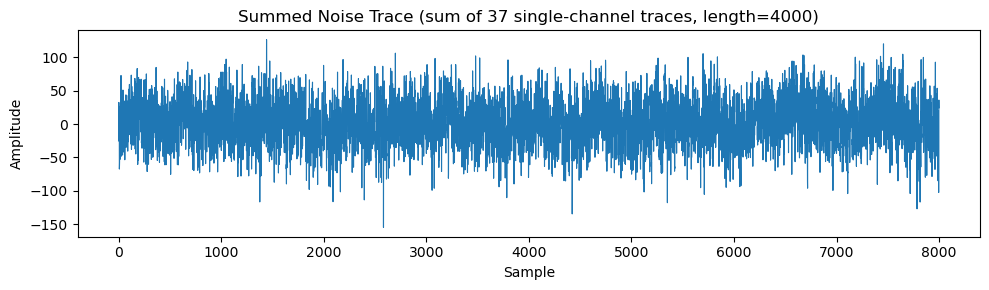

In [3]:
N_VACUUM = 37
TRACE_LEN = 8000

single_noise = np.stack([ng.generate_noise(TRACE_LEN) for _ in range(N_VACUUM)], axis=0)
noise = single_noise.sum(axis=0)

print(f"single_noise shape: {single_noise.shape} (N_VACUUM, TRACE_LEN)")

plt.figure(figsize=(10, 3))
plt.plot(noise, lw=0.8)
plt.title("Summed Noise Trace (sum of 37 single-channel traces, length=4000)")
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()


In [4]:
# Generate 4358 traces x 4000 samples and save to HDF5
# Each output trace = sum of 37 independently generated single-channel noise traces.

N_TRACES = 4000
TRACE_LEN = 8000
N_VACUUM = 37
OUT_PATH = Path.cwd() / "noise_traces_4000x8000.h5"

with h5py.File(OUT_PATH, "w") as f:
    dset = f.create_dataset(
        "traces",
        shape=(N_TRACES, TRACE_LEN),
        dtype=np.float32,
        chunks=(64, TRACE_LEN),
        compression="gzip",
        compression_opts=4,
    )

    for i in range(N_TRACES):
        single_noise = np.stack([ng.generate_noise(TRACE_LEN) for _ in range(N_VACUUM)], axis=0)
        dset[i] = single_noise.sum(axis=0).astype(np.float32, copy=False)
        if (i + 1) % 500 == 0:
            print(f"generated {i + 1}/{N_TRACES}")

    dset.attrs["noise_type"] = str(config.get("noise_type", "unknown"))
    dset.attrs["noise_power"] = float(config.get("noise_power", np.nan))
    dset.attrs["sampling_frequency"] = float(config.get("sampling_frequency", np.nan))
    dset.attrs["summed_channels"] = int(N_VACUUM)

print("Saved:", OUT_PATH)
print("Dataset: traces, shape =", (N_TRACES, TRACE_LEN), "dtype=float32")
print(f"Each trace is the sum of {N_VACUUM} independently generated noise traces")


generated 500/4000
generated 1000/4000
generated 1500/4000
generated 2000/4000
generated 2500/4000
generated 3000/4000
generated 3500/4000
generated 4000/4000
Saved: /home/dwong/DELight_mtr/PCA_dev/wk8/PC_interpretation/CNN_demo/noise_traces_4000x8000.h5
Dataset: traces, shape = (4000, 8000) dtype=float32
Each trace is the sum of 37 independently generated noise traces
